In [3]:
# ============================================
# Cell 1: Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [6]:
# ============================================
# Cell 2: Load Dataset
# ============================================
df = pd.read_csv(r"C:\Users\admin\Downloads\Gas_Sensors_Measurements (2).csv")   # <-- apna file path/name yaha daalo
df.head()

,Serial Number,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135,Gas
0,0,555,515,377,338,666,451,416,NoGas
1,1,555,516,377,339,666,451,416,NoGas
2,2,556,517,376,337,666,451,416,NoGas
3,3,556,516,376,336,665,451,416,NoGas
4,4,556,516,376,337,665,451,416,NoGas


In [7]:
# ============================================
# Cell 3: Data Exploration
# ============================================
print("Shape:", df.shape)
print("\nColumn Info:")
df.info()
print("\nStatistical Summary:")
df.describe()

Shape: (6400, 9)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Serial Number  6400 non-null   int64 
 1   MQ2            6400 non-null   int64 
 2   MQ3            6400 non-null   int64 
 3   MQ5            6400 non-null   int64 
 4   MQ6            6400 non-null   int64 
 5   MQ7            6400 non-null   int64 
 6   MQ8            6400 non-null   int64 
 7   MQ135          6400 non-null   int64 
 8   Gas            6400 non-null   object
dtypes: int64(8), object(1)
memory usage: 450.1+ KB

Statistical Summary:


,Serial Number,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135
count,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000
mean,799.500000,677.593438,462.024688,404.579063,399.758750,565.952031,542.473750,416.727031
std,461.916214,92.913955,70.284038,55.672249,45.091353,83.133693,151.020217,76.681407
min,0.000000,502.000000,337.000000,291.000000,311.000000,361.000000,220.000000,275.000000
25%,399.750000,591.000000,405.000000,366.000000,366.000000,524.000000,447.000000,354.000000
50%,799.500000,701.000000,486.000000,400.000000,393.000000,576.000000,576.000000,437.000000
75%,1199.250000,756.000000,529.000000,443.000000,426.000000,629.000000,642.000000,473.000000
max,1599.000000,824.000000,543.000000,596.000000,524.000000,796.000000,794.000000,589.000000


Missing values per column:
Serial Number    0
MQ2              0
MQ3              0
MQ5              0
MQ6              0
MQ7              0
MQ8              0
MQ135            0
Gas              0
dtype: int64


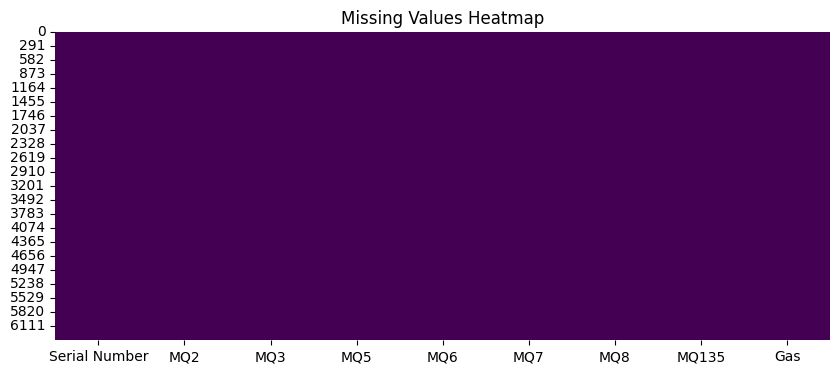

In [8]:
# ============================================
# Cell 4: Missing Values Check
# ============================================
print("Missing values per column:")
print(df.isnull().sum())

# Agar missing values hain to visualize karo
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [9]:
# ============================================
# Cell 5: Duplicate Check
# ============================================
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates agar hain
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (6400, 9)


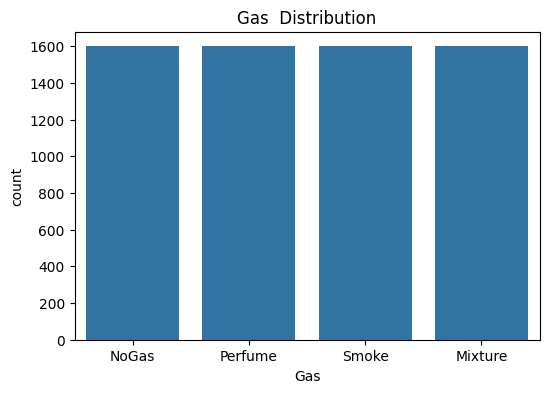

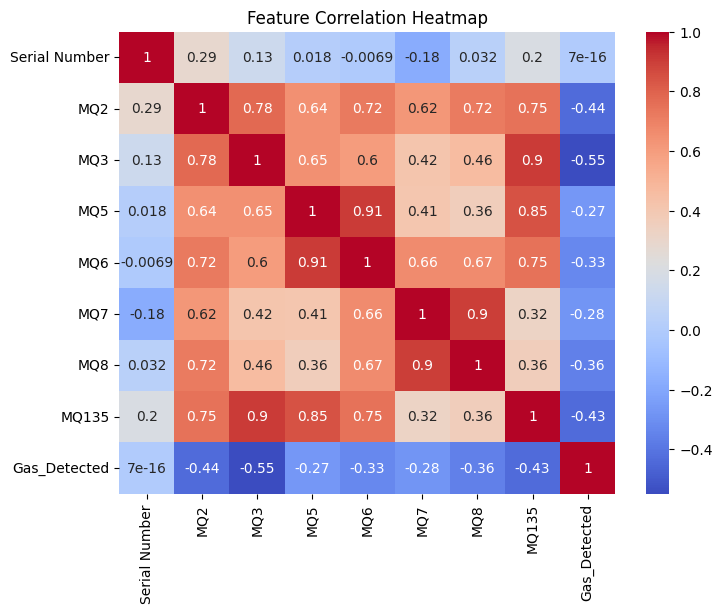

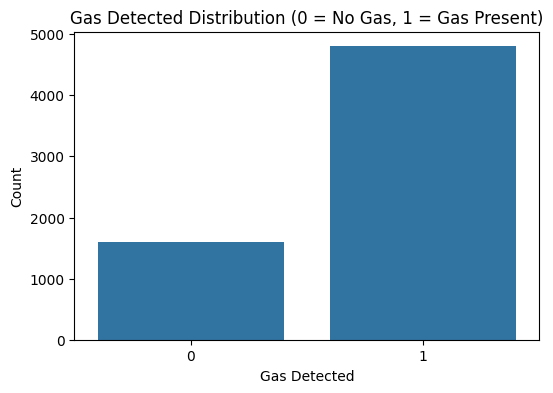

In [33]:
# ============================================
# Cell 6: EDA / Visualization
# ============================================

# Gas distribution (original class column)
plt.figure(figsize=(6,4))
sns.countplot(x="Gas", data=df)
plt.title("Gas  Distribution")
plt.show()

# Sensor readings ka correlation
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Gas_Detected distribution (0 = No Gas, 1 = Gas Present)
plt.figure(figsize=(6,4))
sns.countplot(x="Gas_Detected", data=df)
plt.title("Gas Detected Distribution (0 = No Gas, 1 = Gas Present)")
plt.xlabel("Gas Detected")
plt.ylabel("Count")
plt.show()


Gas
NoGas      1600
Perfume    1600
Smoke      1600
Mixture    1600
Name: count, dtype: int64


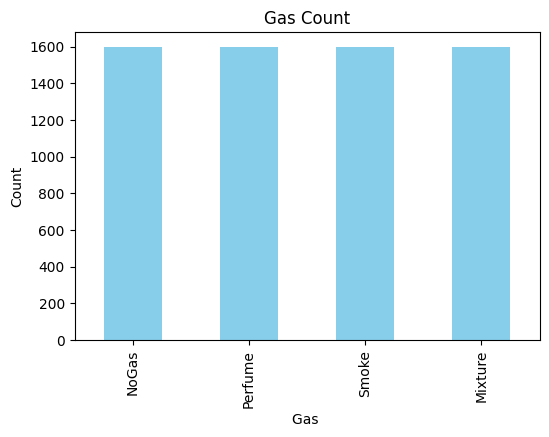

In [14]:
# ============================================
# Cell 7: Class Distribution (Original Classes)
# ============================================
print(df["Gas"].value_counts())

plt.figure(figsize=(6,4))
df["Gas"].value_counts().plot(kind='bar', color='skyblue')
plt.title("Gas Count")
plt.xlabel("Gas ")
plt.ylabel("Count")
plt.show()

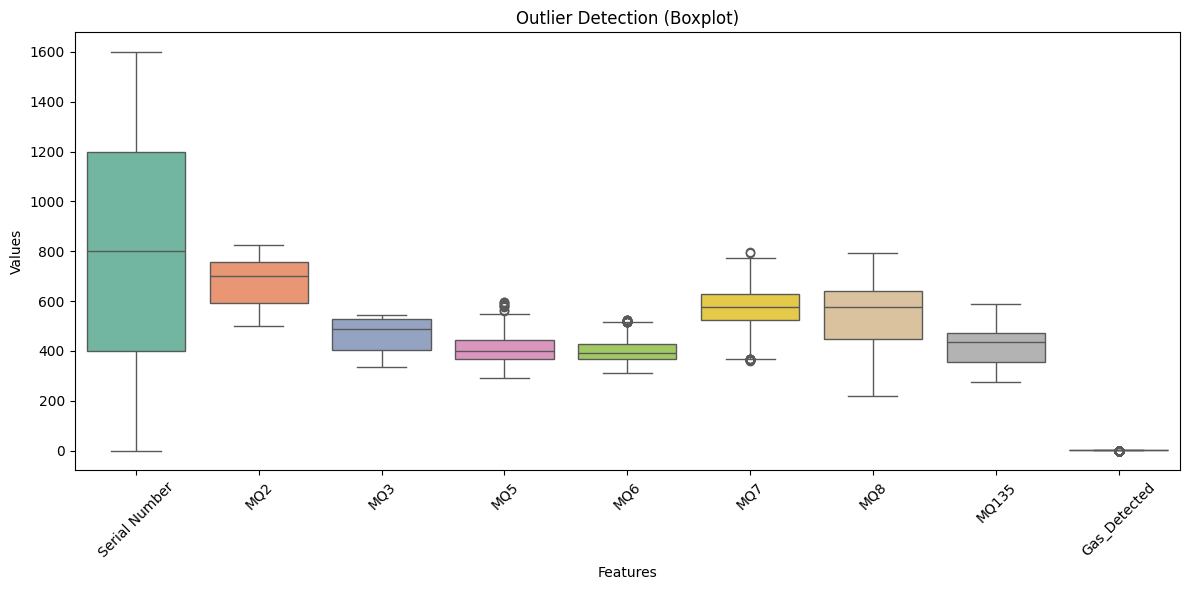

In [34]:
# ============================================
# Cell 8: Outlier Check
# ============================================
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols], palette="Set2")
plt.xticks(rotation=45)
plt.title("Outlier Detection (Boxplot)")
plt.xlabel("Features")
plt.ylabel("Values")
plt.tight_layout()
plt.show()

In [16]:
# ============================================
# Cell 9: Data Cleaning / Preprocessing
# ============================================
# Gas_Class column clean karo (extra spaces/case issues)
df["Gas"] = df["Gas"].astype(str).str.strip()

# Check unique values
print("Unique Gas values:", df["Gas"].unique())

Unique Gas values: ['NoGas' 'Perfume' 'Smoke' 'Mixture']


In [19]:
# ============================================
# Cell 10: Binary Target Creation (Gas_Detected)
# ============================================
gas_map = {
    "NoGas": 0,
    "Perfume": 1,
    "Smoke": 1,
    "Mixture": 1
}

df["Gas_Detected"] = df["Gas"].map(gas_map)

# Verify no unmapped values
print("Unmapped rows:", df["Gas_Detected"].isnull().sum())

print("\nGas_Detected Distribution:")
print(df["Gas_Detected"].value_counts())

df[["Gas", "Gas_Detected"]].head(10)

Unmapped rows: 0

Gas_Detected Distribution:
Gas_Detected
1    4800
0    1600
Name: count, dtype: int64


,Gas,Gas_Detected
0,NoGas,0
1,NoGas,0
2,NoGas,0
3,NoGas,0
4,NoGas,0
5,NoGas,0
6,NoGas,0
7,NoGas,0
8,NoGas,0
9,NoGas,0


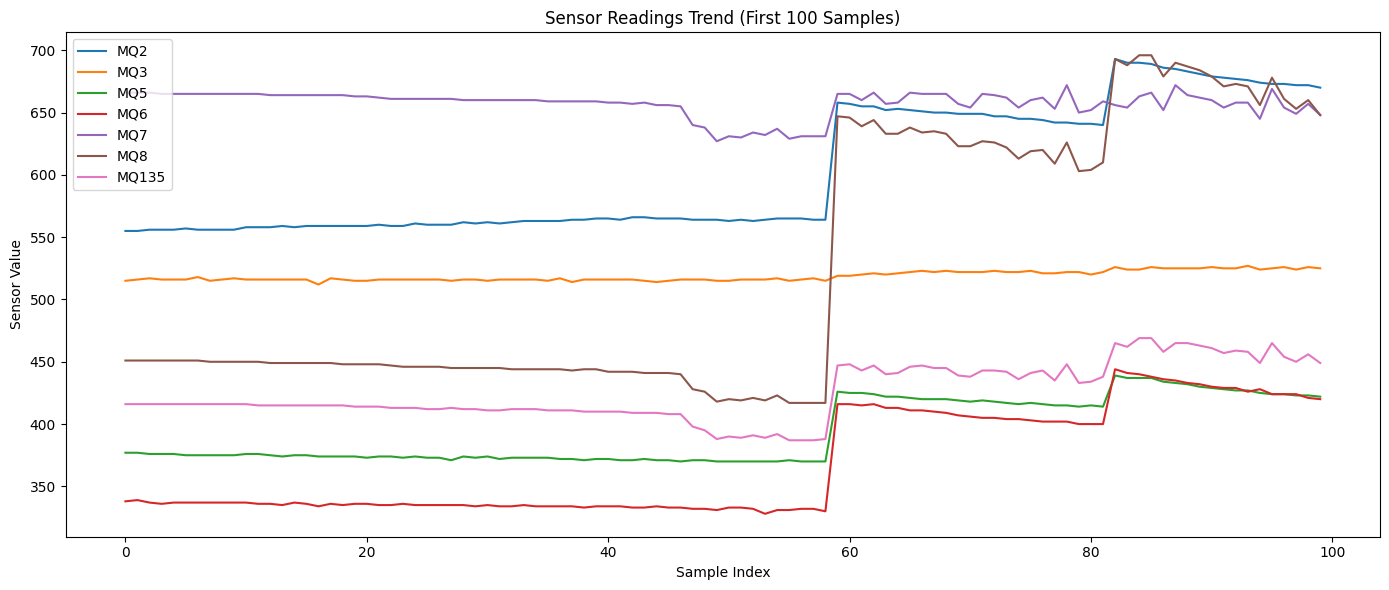

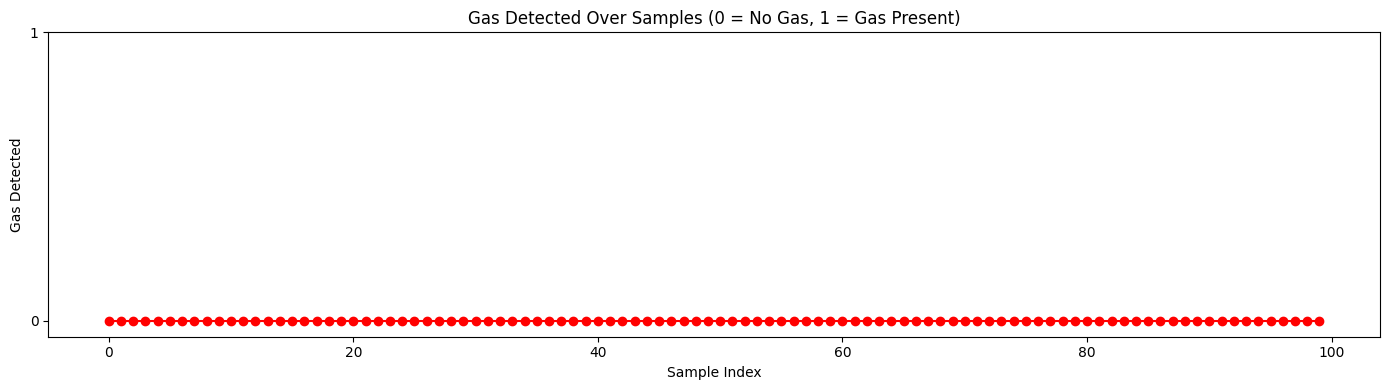

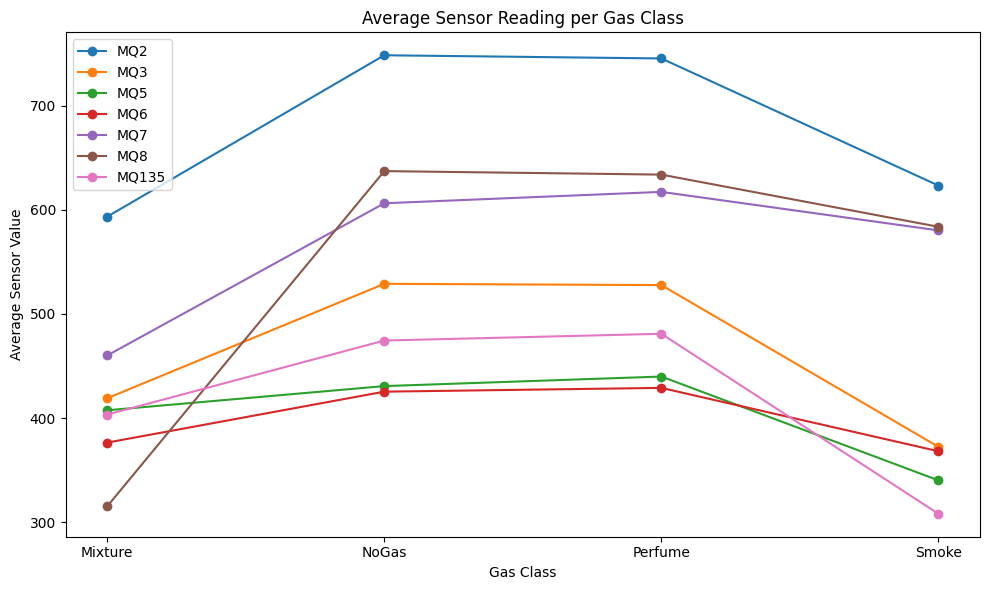

In [40]:
# Pehle ye define karo (agar pehle se nahi hai)
RANDOM_STATE = 42

# Feature columns define karo (sensor readings only)
feature_cols = ["MQ2", "MQ3", "MQ5", "MQ6", "MQ7", "MQ8", "MQ135"]

X = df[feature_cols]        # sirf sensor features, target/original Gas column nahi
y = df["Gas_Detected"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# Gas Line Chart - Sensor readings trend + Gas_Detected
# ============================================

# 1) Sensor readings ka line chart (pehle 100 samples)
plt.figure(figsize=(14,6))
for col in feature_cols:
    plt.plot(df[col].values[:100], label=col)
plt.title("Sensor Readings Trend (First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Sensor Value")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Gas_Detected line chart (0 = No Gas, 1 = Gas Present) over samples
plt.figure(figsize=(14,4))
plt.plot(df["Gas_Detected"].values[:100], marker='o', color='red', linestyle='-')
plt.title("Gas Detected Over Samples (0 = No Gas, 1 = Gas Present)")
plt.xlabel("Sample Index")
plt.ylabel("Gas Detected")
plt.yticks([0,1])
plt.tight_layout()
plt.show()

# 3) Average sensor value per Gas class (line chart)
avg_by_class = df.groupby("Gas")[feature_cols].mean()

plt.figure(figsize=(10,6))
for col in feature_cols:
    plt.plot(avg_by_class.index, avg_by_class[col], marker='o', label=col)
plt.title("Average Sensor Reading per Gas Class")
plt.xlabel("Gas Class")
plt.ylabel("Average Sensor Value")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
if xgb_available:
    models["XGBoost"] = XGBClassifier(n_estimators=300,
                                       eval_metric='logloss', random_state=RANDOM_STATE)

In [49]:
# ============================================
# Cell: Model Training (Optimized - More Models + CV)
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost install nahi hai -> pip install xgboost")

# ---- Multiple models banao ----
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=None, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE)
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(n_estimators=300,
                                       eval_metric='logloss', random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        "model": model, "accuracy": acc, "auc": auc, "f1": f1,
        "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std()
    }

    print(f"\n===== {name} =====")
    print(f"Test Accuracy: {acc:.4f} | AUC: {auc:.4f} | F1: {f1:.4f}")
    print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(classification_report(y_test, y_pred))


===== Logistic Regression =====
Test Accuracy: 0.8281 | AUC: 0.9106 | F1: 0.8827
CV Accuracy: 0.8482 (+/- 0.0071)
              precision    recall  f1-score   support

           0       0.64      0.72      0.68       320
           1       0.90      0.86      0.88       960

    accuracy                           0.83      1280
   macro avg       0.77      0.79      0.78      1280
weighted avg       0.84      0.83      0.83      1280


===== Decision Tree =====
Test Accuracy: 0.9609 | AUC: 0.9458 | F1: 0.9740
CV Accuracy: 0.9639 (+/- 0.0026)
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       320
           1       0.97      0.98      0.97       960

    accuracy                           0.96      1280
   macro avg       0.95      0.95      0.95      1280
weighted avg       0.96      0.96      0.96      1280


===== KNN =====
Test Accuracy: 0.9734 | AUC: 0.9902 | F1: 0.9823
CV Accuracy: 0.9678 (+/- 0.0060)
              precision

Best Model: Random Forest (AUC = 0.9961)


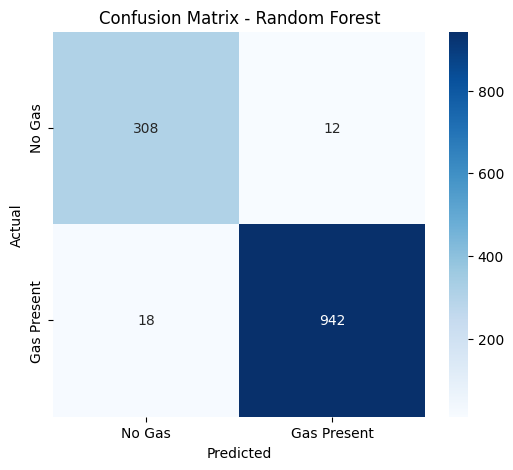

In [42]:
# ============================================
# Cell: Best Model Select + Confusion Matrix
# ============================================

# Sabse accha model (AUC ke basis par) select karo
best_name = max(results, key=lambda x: results[x]["auc"])
best_model = results[best_name]["model"]

print(f"Best Model: {best_name} (AUC = {results[best_name]['auc']:.4f})")

y_pred_best = best_model.predict(X_test_scaled)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Gas', 'Gas Present'],
            yticklabels=['No Gas', 'Gas Present'])
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

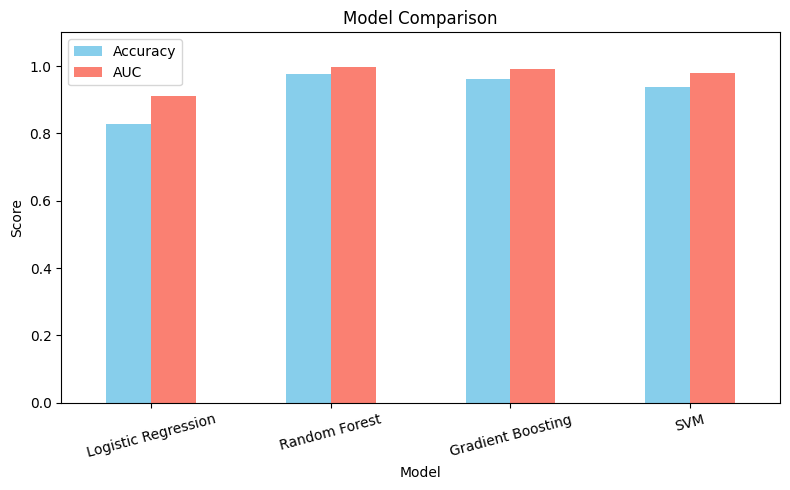

                 Model  Accuracy       AUC
0  Logistic Regression  0.828125  0.910592
1        Random Forest  0.976562  0.996110
2    Gradient Boosting  0.960938  0.992054
3                  SVM  0.936719  0.979525


In [43]:
# ============================================
# Cell: Model Comparison Chart
# ============================================
comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[m]["accuracy"] for m in results],
    "AUC": [results[m]["auc"] for m in results]
})

comparison_df.set_index("Model")[["Accuracy", "AUC"]].plot(
    kind="bar", figsize=(8,5), color=["skyblue", "salmon"]
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

print(comparison_df)

In [44]:
# ============================================
# Cell: Hyperparameter Tuning (Random Forest)
# ============================================
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Accuracy: 0.9767578125


Tuned Random Forest -> Accuracy: 0.9766 | AUC: 0.9962
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       320
           1       0.99      0.98      0.98       960

    accuracy                           0.98      1280
   macro avg       0.97      0.97      0.97      1280
weighted avg       0.98      0.98      0.98      1280



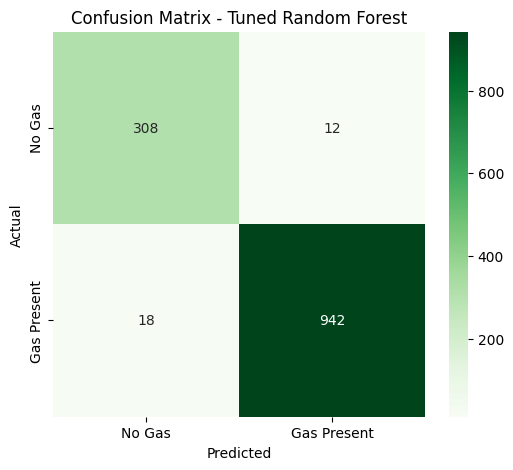

In [45]:
# ============================================
# Cell: Tuned Model Evaluation
# ============================================
y_pred_tuned = best_rf.predict(X_test_scaled)
y_proba_tuned = best_rf.predict_proba(X_test_scaled)[:, 1]

acc_tuned = accuracy_score(y_test, y_pred_tuned)
auc_tuned = roc_auc_score(y_test, y_proba_tuned)

print(f"Tuned Random Forest -> Accuracy: {acc_tuned:.4f} | AUC: {auc_tuned:.4f}")
print(classification_report(y_test, y_pred_tuned))

# Confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Gas', 'Gas Present'],
            yticklabels=['No Gas', 'Gas Present'])
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
# ============================================
# Cell: Cross-Validation Score (Overfitting Check)
# ============================================
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=10, scoring='accuracy')
print("10-Fold CV Accuracy Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Train vs Test accuracy compare karo (overfitting check)
train_acc = best_rf.score(X_train_scaled, y_train)
test_acc = best_rf.score(X_test_scaled, y_test)
print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

10-Fold CV Accuracy Scores: [0.984375   0.97070312 0.96875    0.96484375 0.98828125 0.98046875
 0.9765625  0.97265625 0.96875    0.98632812]
Mean CV Accuracy: 0.9762 (+/- 0.0079)

Train Accuracy: 1.0000
Test Accuracy: 0.9766
